# **Tutorial 3 Challenges of spatial multi-omics diagonal integration without histology anchor**

Our data are organized as follows: the `datasets` directory stores the raw datasets, the `inputs` directory contains input data such as the pre-extracted H&E embeddings and filtered cell indices, and the `outputs` directory stores the model outputs.

```
our_model/
│
├── datasets/      # The datasets
│   ├── ...                   
│
├── inputs/        # The inputs
│   ├── ...
│
├── outputs/       # The outputs
│   ├── model      # put the parameters
│   ├── result     # put the results
```

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import umap
import numpy as np
import pandas as pd
import scanpy as sc
import SpaWeaver as sw
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

seed = 42 
rng = np.random.default_rng(seed)

# 1. Prepare the dataset

### [Download](https://spatch.pku-genomics.org/#/dataset/xenium) the COAD dataset of SPATCH. Considering the large size of the raw dataset, we provide the related data. These data should be organized into the following directory structure:

```
datasets/
│
├── SPATCH/
│    ├── Xenium                    # The 1st slice
│    │    ├── COAD_RNA.h5ad        # RNA
│    │    ├── COAD_HE.tif          # H&E image
│
│    ├── CODEX                     # The 2nd slice
│    │    ├── COAD_Protein.h5ad    # Protein
│    │    ├── COAD_virtualHE.npy   # Virtual H&E image
│    │    ├── COAD_CycleGAN.npy    # Rectified virtual H&E image with CycleGAN
```

For convenience, we also provide the H&E image embeddings used in our experiments, which are stored in the `inputs` directory. Each subdirectory contains the following files.

**he_emb**: COAD_RNA.npy, COAD_Protein.npy, and COAD_Protein_Rectified_Virtual.npy


```
inputs/
│
├── he_emb/                                  # Store the extracted H&E image embeddings.
│   ├── COAD_RNA.npy                         # RNA                 
│   ├── COAD_Protein.npy                     # Protein (Virutal H&E embeddings)
│   ├── COAD_Protein_Rectified_Virtual.npy   # Protein (Rectified virtual H&E embeddings)
```

**All related data have been uploaded to Zenodo and can be accessed through this <a href="https://zenodo.org/" style="color:red;">link</a>**.

# 2. Read in H&E images

In [2]:
root_path = './datasets/SPATCH/'
real, scale = sw.pp.read_HE_image(root_path + 'Xenium/COAD_HE.tif', suffix='.tif')
virtual = np.load(root_path + 'CODEX/COAD_virtualHE.npy')[:, :, :3]
rectified_virtual = np.load(root_path + 'CODEX/COAD_CycleGAN.npy')[:, :, :3]
real.shape, virtual.shape, rectified_virtual.shape

((36102, 49221, 3), (15006, 20264, 3), (16896, 23040, 3))

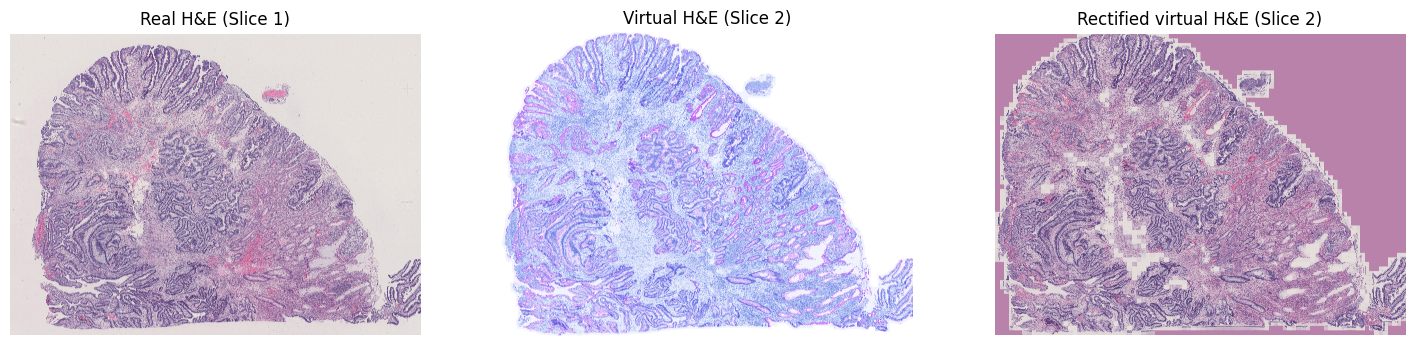

In [4]:
plt.figure(figsize=(18, 8))

plt.subplot(1, 3, 1)
plt.imshow(real)
plt.axis('off')
plt.gca().invert_yaxis()
plt.title('Real H&E (Slice 1)')

plt.subplot(1, 3, 2)
plt.imshow(virtual)
plt.axis('off')
plt.gca().invert_yaxis()
plt.title('Virtual H&E (Slice 2)')

plt.subplot(1, 3, 3)
plt.imshow(rectified_virtual)
plt.axis('off')
plt.gca().invert_yaxis()
plt.title('Rectified virtual H&E (Slice 2)')
plt.show()

# 3. Visualize domain shift in H&E embedding 

In [5]:
meta_root = './inputs/'

### 3.1 Load real H&E embeddings on slice 1

In [6]:
adata1 = sw.pp.read_h5ad('./datasets/SPATCH/Xenium/COAD_RNA.h5ad')
adata1 = sw.pp.load_he_emb(adata1, meta_root, 'COAD_RNA')
adata1

AnnData object with n_obs × n_vars = 405862 × 5001
    obs: 'codex_common', 'annotation', 'spatial_cluster', 'high_quality'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'CODEX resolution', 'DAPI resolution', 'H&E resolution'
    obsm: 'spatial', 'he'

### 3.2 Load virtual H&E embeddings and CycleGAN rectified virtual H&E embeddings on slice 2

In [7]:
adata2 = sw.pp.read_h5ad('./datasets/SPATCH/CODEX/COAD_Protein.h5ad')

#### 3.2.1 Virtual H&E embeddings

In [8]:
adata2 = sw.pp.load_he_emb(adata2, meta_root, 'COAD_Protein')
adata2.obsm['virtualHE'] = adata2.obsm['he'].copy()
del adata2.obsm['he']

#### 3.2.2 CycleGAN rectified virtual H&E embeddings

In [9]:
adata2 = sw.pp.load_he_emb(adata2, meta_root, 'COAD_Protein_Rectified_Virtual')
adata2.obsm['rectified_virtualHE'] = adata2.obsm['he'].copy()
del adata2.obsm['he']
adata2

AnnData object with n_obs × n_vars = 265845 × 16
    obs: 'codex_common', 'annotation', 'spatial_cluster'
    uns: 'CODEX resolution', 'Coding_genes'
    obsm: 'spatial', 'virtualHE', 'rectified_virtualHE'

#### ⚡ Running UMAP on the full dataset is very slow, so it is recommended to perform UMAP after downsampling.

In [10]:
samplenum = 10000                 # You can change this to adata1.n_obs and adata2.n_obs to perform UMAP on the full dataset
nums1 = np.arange(adata1.n_obs)
nums2 = np.arange(adata2.n_obs)
rng.shuffle(nums1)
rng.shuffle(nums2)
sel_obs1 = nums1[:samplenum]
sel_obs2 = nums2[:samplenum]

real_he_emb = adata1.obsm['he'][sel_obs1]
virtual_he_emb = adata2.obsm['virtualHE'][sel_obs2]
rectified_virtual_he_emb = adata2.obsm['rectified_virtualHE'][sel_obs2]
x = np.vstack([real_he_emb, virtual_he_emb, rectified_virtual_he_emb])
x.shape

(30000, 1024)

### 3.3 PCA dimension reduction and UMAP visualization

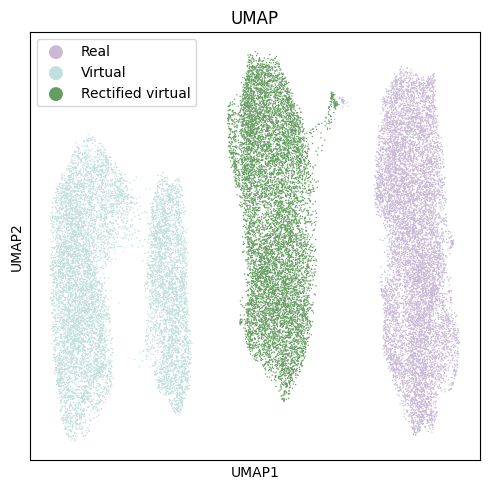

In [11]:
X_scaled = StandardScaler().fit_transform(x)
pca = PCA(n_components=50, random_state=42)
X_pca = pca.fit_transform(X_scaled)

umap_model = umap.UMAP(
    n_neighbors=15,
    min_dist=0.3,
    n_components=2,
    metric="euclidean",
    random_state=seed
)
X_umap = umap_model.fit_transform(X_pca)

plt.figure(figsize=(5, 5))
plt.scatter(X_umap[:10000, 0], X_umap[:10000, 1], s=1, c='#c9b9d6', edgecolor='none', label='Real')
plt.scatter(X_umap[10000:20000, 0], X_umap[10000:20000, 1], s=1, c='#c1dfdd', edgecolor='none', label='Virtual')
plt.scatter(X_umap[20000:, 0], X_umap[20000:, 1], s=1, edgecolor='none', c='#649d60', label='Rectified virtual')
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.xticks([], [])
plt.yticks([], [])
plt.title("UMAP")
plt.legend(markerscale=10)
plt.tight_layout()
plt.show()